# TCR-Antigen Prediction — Alpha + Beta Chains

This notebook trains and evaluates TCR-antigen recognition models using **paired CDR3 alpha and beta chains**.  
Supported split strategies: `random_split` and `tcr_ab_split` (runs 1–5 each).  
`tcr_ab_split` ensures no alpha+beta pair appears in both train and test.

**Methods (in order)**
1. Batch GEX + Peptide — GEX baseline
2. TCR Alpha + Beta + Peptide — sequence-only baseline (both chains)
3. ED: Batch GEX → TCR Alpha+Beta + Peptide — integration method (V/J genes optional)
4. mvTCR + Peptide — pre-computed mvTCR latent embeddings
5. Tessa + Peptide — pre-computed Tessa TCR embeddings

---

### Using your own dataset
To run on a new dataset instead of ours, you need:
1. A reference CSV (`ref_data_alpha_beta`) with columns: `tcr` (CDR3β), `tcr_alpha` (CDR3α), `peptide`, `label` (0/1), `tcr_source_index`
2. A batch-corrected GEX CSV (cells × PCs, rows indexed by `tcr_source_index`)
3. An AnnData H5AD file with raw counts (used to extract `donor` metadata)
4. *(Optional)* V/J gene spectral embeddings CSV indexed by `tcr_source_index`
5. *(Optional)* Pre-computed mvTCR latent embedding CSVs (one per split/run) in `merged_embeddings/mvTCR_integration_res/`
6. *(Optional)* Pre-computed Tessa TCR embedding CSVs (one per split/run) in `merged_embeddings/Tessa_integration_res/`

If your dataset does not have pre-saved split index files, generate them once with:
```python
from tcr_antigen_prediction_utils import create_random_splits
create_random_splits(ref_data_alpha_beta, labels, output_dir, n_runs=5)
```
For alpha+beta TCR-grouped splits, group by the `tcr + '|' + tcr_alpha` composite key
and apply the same `GroupShuffleSplit` → `np.save` pattern with `split_type='tcr_ab_split'`.

## 1. Imports & configuration

In [1]:
from tcr_antigen_prediction_utils import *
import os
import numpy as np
import pandas as pd

In [2]:
# ── USER CONFIGURATION ────────────────────────────────────────────────────────
NEG_RATIO   = "3_1"           # negative-sampling ratio: "3_1" or "5_1"
SPLIT_TYPE  = "tcr_ab_split"  # "random_split" or "tcr_ab_split"
RUN         = 1               # which pre-saved split to load: 1–5
USE_VJ      = False           # include V/J gene spectral embeddings in the ED model
# ─────────────────────────────────────────────────────────────────────────────

## 2. Load dataset

In [3]:
data = load_dataset(neg_ratio=NEG_RATIO)

ref_data_ab = data["ref_data_alpha_beta"]   # paired alpha+beta subset
ref_merged  = data["ref_merged"]
batch_gex   = data["batch_gex"]
vj_genes    = data["vj_genes"]
labels      = data["labels"]
output_dir  = data["output_dir"]

print(f"Alpha-beta paired cells: {len(ref_data_ab):,}")
print(ref_data_ab.label.value_counts(normalize=True))

Loaded 287,364 samples  |  pos=25.0%  |  output_dir=output/experiments/neg_ratio_3_1
Alpha-beta paired cells: 287,364
label
0    0.75
1    0.25
Name: proportion, dtype: float64


## 3. Load split indices

Loads pre-saved train/val/test indices for the chosen `SPLIT_TYPE` and `RUN`.

**To generate splits for a new dataset**, run `create_random_splits()` once (see top of notebook).  
For alpha+beta TCR-grouped splits, see the comment in the top-of-notebook instructions.

In [4]:
split = load_split(output_dir, SPLIT_TYPE, RUN,
                   ref_data_ab, ref_data_ab, labels)

train_indices = split["train_indices"]
val_indices   = split["val_indices"]
test_indices  = split["test_indices"]

# NOTE: for this notebook we use train_raw_ab which carries both 'tcr' (beta) and 'tcr_alpha'
train_raw = split["train_raw_ab"]
val_raw   = split["val_raw_ab"]
test_raw  = split["test_raw_ab"]

for name, idx in [("train", train_indices), ("val", val_indices), ("test", test_indices)]:
    print(f"{name:5s}: {len(idx):6,}  pos={labels[idx].mean():.1%}")

split=tcr_ab_split  run=1  |  train=178,464  val=44,617  test=64,283
train: 178,464  pos=24.0%
val  : 44,617  pos=24.0%
test : 64,283  pos=28.6%


## 4. Sequence encoding — TCR alpha, TCR beta & peptide (PE + AE)

Each sequence is encoded with Atchley-factor positional embeddings then compressed
with a small autoencoder (trained separately on train / val / test splits).
Embeddings are saved to disk and reloaded on subsequent runs.

In [5]:
word_vectors, index_aa_converter = load_atchley()
pt_tcr = PositionalEmbedding(d_model=6, word_vectors=word_vectors, length=35)
pt_pep = PositionalEmbedding(d_model=6, word_vectors=word_vectors, length=15)

In [6]:
# TCR beta chain (CDR3β)
beta_paths = get_embedding_paths(output_dir, SPLIT_TYPE, RUN, chain_name="TCR")
print("TCR beta — ", end="")
emb_beta_train, emb_beta_val, emb_beta_test = build_fit_pe_ae(
    train_raw["tcr"].values,
    val_raw["tcr"].values,
    test_raw["tcr"].values,
    pt=pt_tcr, index_aa_converter=index_aa_converter,
    latent_dim=128, length=35, d_model=6, epochs=50,
    ae_name="tcr_beta_ae", save_paths=beta_paths,
)
print(f"shape: {emb_beta_train.shape}")

TCR beta —   Loading cached embeddings from merged_embeddings/...
shape: (178464, 128)


In [7]:
# TCR alpha chain (CDR3α)
alpha_paths = get_embedding_paths(output_dir, SPLIT_TYPE, RUN, chain_name="TCR_alpha")
print("TCR alpha — ", end="")
emb_alpha_train, emb_alpha_val, emb_alpha_test = build_fit_pe_ae(
    train_raw["tcr_alpha"].values,
    val_raw["tcr_alpha"].values,
    test_raw["tcr_alpha"].values,
    pt=pt_tcr, index_aa_converter=index_aa_converter,
    latent_dim=128, length=35, d_model=6, epochs=50,
    ae_name="tcr_alpha_ae", save_paths=alpha_paths,
)
print(f"shape: {emb_alpha_train.shape}")

TCR alpha —   Loading cached embeddings from merged_embeddings/...
shape: (178464, 128)


In [8]:
# Peptide
pep_paths = get_embedding_paths(output_dir, SPLIT_TYPE, RUN, chain_name="peptide")
print("Peptide — ", end="")
emb_pep_train, emb_pep_val, emb_pep_test = build_fit_pe_ae(
    train_raw["peptide"].values,
    val_raw["peptide"].values,
    test_raw["peptide"].values,
    pt=pt_pep, index_aa_converter=index_aa_converter,
    latent_dim=64, length=15, d_model=6, epochs=40, batch_size=128,
    ae_name="peptide_ae", save_paths=pep_paths,
)
print(f"shape: {emb_pep_train.shape}")

Peptide —   Loading cached embeddings from merged_embeddings/...
shape: (178464, 64)


---
## 5. Model 1: Batch GEX + Peptide  (GEX baseline)

50-dim batch-corrected GEX (PCA + Harmony) concatenated with 64-dim peptide AE embedding.

In [9]:
X_train, X_val, X_test = assemble_features(
    (batch_gex.iloc[train_indices], batch_gex.iloc[val_indices], batch_gex.iloc[test_indices]),
    (emb_pep_train, emb_pep_val, emb_pep_test),
)
print(f"Input dim: {X_train.shape[1]}")

Input dim: 114


In [10]:
model_gex = build_small_residual_mlp(X_train.shape[1], name="batch_gex_pep")
history = compile_and_train(
    model_gex, X_train, split["train_labels"], X_val, split["val_labels"],
    lr=1e-4, batch_size=256, epochs=75, patience=10,
)

Epoch 1/75


2026-06-08 15:24:44.525408: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


698/698 [==============================] - 5s 5ms/step - loss: 0.6737 - accuracy: 0.7259 - precision: 0.4564 - recall: 0.7516 - auc_roc: 0.8080 - auc_pr: 0.5596 - val_loss: 0.5405 - val_accuracy: 0.8439 - val_precision: 0.6381 - val_recall: 0.8050 - val_auc_roc: 0.9002 - val_auc_pr: 0.7207 - lr: 1.0000e-04
Epoch 2/75
698/698 [==============================] - 3s 4ms/step - loss: 0.5177 - accuracy: 0.8338 - precision: 0.6260 - recall: 0.7610 - auc_roc: 0.8844 - auc_pr: 0.6952 - val_loss: 0.4497 - val_accuracy: 0.8594 - val_precision: 0.6557 - val_recall: 0.8708 - val_auc_roc: 0.9223 - val_auc_pr: 0.7761 - lr: 1.0000e-04
Epoch 3/75
698/698 [==============================] - 3s 4ms/step - loss: 0.4360 - accuracy: 0.8628 - precision: 0.6976 - recall: 0.7546 - auc_roc: 0.9120 - auc_pr: 0.7604 - val_loss: 0.3966 - val_accuracy: 0.8679 - val_precision: 0.6720 - val_recall: 0.8769 - val_auc_roc: 0.9314 - val_auc_pr: 0.8094 - lr: 1.0000e-04
Epoch 4/75
698/698 [==============================] - 

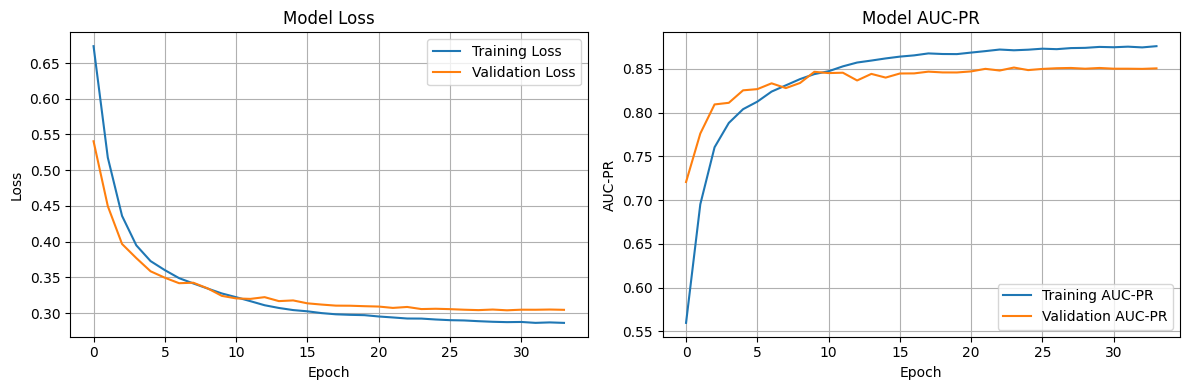

              precision    recall  f1-score   support

Negative (0)       0.92      0.92      0.92     45906
Positive (1)       0.80      0.80      0.80     18377

    accuracy                           0.89     64283
   macro avg       0.86      0.86      0.86     64283
weighted avg       0.89      0.89      0.89     64283

ROC-AUC: 0.9415  |  PR-AUC: 0.8106
{'total_params': 60033, 'latency_ms': 2.2689, 'best_val_loss': 0.3038, 'val_loss_std': 0.0006}


In [11]:
plot_training_curves(history)
metrics_gex = evaluate_classifier(model_gex, X_test, split["test_labels"])
print(get_basic_run_metrics(model_gex, history, X_val[:32]))

In [12]:
logreg_gex = train_eval_logreg(
    X_train, split["train_labels"], X_val, split["val_labels"], X_test, split["test_labels"]
)

              precision    recall  f1-score   support

         Neg       0.98      0.77      0.86     45906
         Pos       0.62      0.95      0.75     18377

    accuracy                           0.82     64283
   macro avg       0.80      0.86      0.81     64283
weighted avg       0.88      0.82      0.83     64283

ROC AUC: 0.9188  |  AUPR: 0.7787


---
## 6. Model 2: TCR Alpha + Beta + Peptide  (TCR sequence baseline)

128-dim TCR-beta AE + 128-dim TCR-alpha AE concatenated with 64-dim peptide AE embedding.

In [13]:
X_train, X_val, X_test = assemble_features(
    (emb_beta_train, emb_beta_val, emb_beta_test),
    (emb_alpha_train, emb_alpha_val, emb_alpha_test),
    (emb_pep_train, emb_pep_val, emb_pep_test),
)
print(f"Input dim: {X_train.shape[1]}")

Input dim: 320


In [14]:
model_tcr = build_residual_mlp(X_train.shape[1], name="tcr_ab_pep")
history = compile_and_train(
    model_tcr, X_train, split["train_labels"], X_val, split["val_labels"],
    lr=1e-3, batch_size=128, epochs=75, patience=10,
)

Epoch 1/75
1395/1395 [==============================] - 15s 10ms/step - loss: 0.6218 - accuracy: 0.9015 - precision: 0.7914 - recall: 0.8000 - auc_roc: 0.9470 - auc_pr: 0.8795 - val_loss: 0.5575 - val_accuracy: 0.8852 - val_precision: 0.7570 - val_recall: 0.7674 - val_auc_roc: 0.9297 - val_auc_pr: 0.8128 - lr: 0.0010
Epoch 2/75
1395/1395 [==============================] - 13s 9ms/step - loss: 0.3726 - accuracy: 0.9290 - precision: 0.8441 - recall: 0.8631 - auc_roc: 0.9677 - auc_pr: 0.9275 - val_loss: 0.5978 - val_accuracy: 0.8256 - val_precision: 0.7162 - val_recall: 0.4510 - val_auc_roc: 0.8799 - val_auc_pr: 0.6696 - lr: 0.0010
Epoch 3/75
1395/1395 [==============================] - 13s 9ms/step - loss: 0.2940 - accuracy: 0.9316 - precision: 0.8438 - recall: 0.8769 - auc_roc: 0.9689 - auc_pr: 0.9304 - val_loss: 0.4197 - val_accuracy: 0.8757 - val_precision: 0.8033 - val_recall: 0.6371 - val_auc_roc: 0.9269 - val_auc_pr: 0.8200 - lr: 0.0010
Epoch 4/75
1395/1395 [=======================

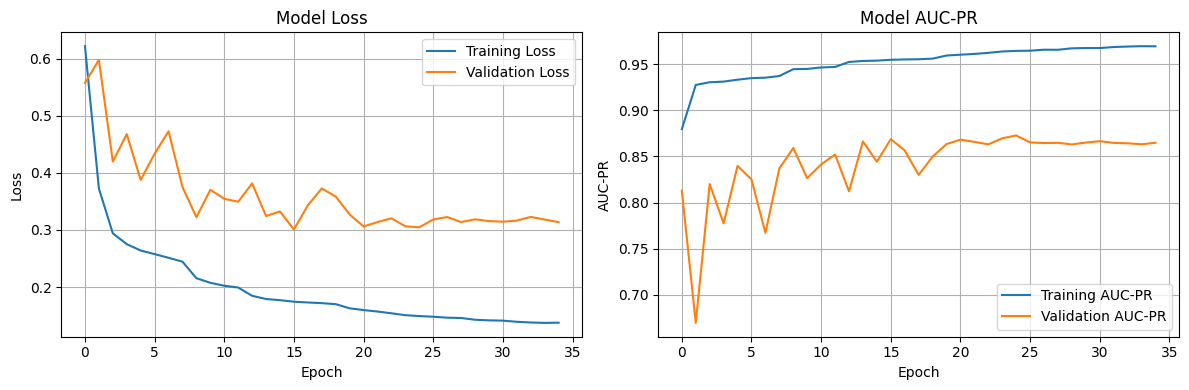

              precision    recall  f1-score   support

Negative (0)       0.82      0.95      0.88     45906
Positive (1)       0.79      0.47      0.59     18377

    accuracy                           0.81     64283
   macro avg       0.80      0.71      0.73     64283
weighted avg       0.81      0.81      0.80     64283

ROC-AUC: 0.9303  |  PR-AUC: 0.8159
{'total_params': 672257, 'latency_ms': 3.4697, 'best_val_loss': 0.3007, 'val_loss_std': 0.0031}


In [15]:
plot_training_curves(history)
metrics_tcr = evaluate_classifier(model_tcr, X_test, split["test_labels"])
print(get_basic_run_metrics(model_tcr, history, X_val[:32]))

In [16]:
logreg_tcr = train_eval_logreg(
    X_train, split["train_labels"], X_val, split["val_labels"], X_test, split["test_labels"]
)

              precision    recall  f1-score   support

         Neg       0.96      0.80      0.87     45906
         Pos       0.64      0.92      0.76     18377

    accuracy                           0.83     64283
   macro avg       0.80      0.86      0.81     64283
weighted avg       0.87      0.83      0.84     64283

ROC AUC: 0.9097  |  AUPR: 0.7106


---
## 7. Model 3: ED Batch GEX → TCR Alpha+Beta + Peptide  (integration method)

Two separate encoder-decoder (ED) models map batch-corrected GEX to each chain's PE embeddings.
Their latent representations (128-dim each) are concatenated to form a 256-dim GEX-TCR integrated
representation, then combined with the peptide AE embedding for downstream prediction.

Set `USE_VJ = True` in Section 1 to additionally include V/J gene spectral embeddings.

In [17]:
bgex_train = batch_gex.iloc[train_indices].values.astype("float32")
bgex_val   = batch_gex.iloc[val_indices].values.astype("float32")
bgex_test  = batch_gex.iloc[test_indices].values.astype("float32")

# ED for beta chain
ed_beta_paths = get_ed_embedding_paths(output_dir, SPLIT_TYPE, RUN, chain_name="beta")
print("ED beta — ", end="")
ed_model_beta = build_ed_integration_model(
    input_dim=bgex_train.shape[1],
    output_dim=emb_beta_train.shape[1],
)
ed_beta_train, ed_beta_val, ed_beta_test = fit_ed_per_split(
    ed_model_beta,
    bgex_train, emb_beta_train,
    bgex_val,   emb_beta_val,
    bgex_test,  emb_beta_test,
    save_paths=ed_beta_paths,
)
print(f"latent shape: {ed_beta_train.shape}")

ED beta —   Loading cached ED embeddings from ED_integration_batch_gex_tcr_embeddings_tcr_ab_split_1.npy...
latent shape: (178464, 128)


In [18]:
# ED for alpha chain
ed_alpha_paths = get_ed_embedding_paths(output_dir, SPLIT_TYPE, RUN, chain_name="alpha")
print("ED alpha — ", end="")
ed_model_alpha = build_ed_integration_model(
    input_dim=bgex_train.shape[1],
    output_dim=emb_alpha_train.shape[1],
)
ed_alpha_train, ed_alpha_val, ed_alpha_test = fit_ed_per_split(
    ed_model_alpha,
    bgex_train, emb_alpha_train,
    bgex_val,   emb_alpha_val,
    bgex_test,  emb_alpha_test,
    save_paths=ed_alpha_paths,
)
print(f"latent shape: {ed_alpha_train.shape}")

ED alpha —   Loading cached ED embeddings from ED_integration_batch_gex_tcr_alpha_embeddings_tcr_ab_split_1.npy...
latent shape: (178464, 128)


In [19]:
# Assemble features — VJ genes are included only when USE_VJ = True
if USE_VJ:
    X_train, X_val, X_test = assemble_features(
        (ed_beta_train,  ed_beta_val,  ed_beta_test),
        (ed_alpha_train, ed_alpha_val, ed_alpha_test),
        (vj_genes.iloc[train_indices], vj_genes.iloc[val_indices], vj_genes.iloc[test_indices]),
        (emb_pep_train, emb_pep_val, emb_pep_test),
    )
else:
    X_train, X_val, X_test = assemble_features(
        (ed_beta_train,  ed_beta_val,  ed_beta_test),
        (ed_alpha_train, ed_alpha_val, ed_alpha_test),
        (emb_pep_train, emb_pep_val, emb_pep_test),
    )
print(f"Input dim: {X_train.shape[1]}  (USE_VJ={USE_VJ})")

Input dim: 320  (USE_VJ=False)


In [20]:
model_ed = build_residual_mlp(X_train.shape[1], name="ed_ab_pep")
history = compile_and_train(
    model_ed, X_train, split["train_labels"], X_val, split["val_labels"],
    lr=1e-4, batch_size=128, epochs=75, patience=10,
)

Epoch 1/75
1395/1395 [==============================] - 16s 10ms/step - loss: 0.8756 - accuracy: 0.8287 - precision: 0.6073 - recall: 0.8075 - auc_roc: 0.8960 - auc_pr: 0.7696 - val_loss: 0.6910 - val_accuracy: 0.9166 - val_precision: 0.8381 - val_recall: 0.8082 - val_auc_roc: 0.9575 - val_auc_pr: 0.9015 - lr: 1.0000e-04
Epoch 2/75
1395/1395 [==============================] - 15s 11ms/step - loss: 0.6874 - accuracy: 0.9084 - precision: 0.8249 - recall: 0.7841 - auc_roc: 0.9484 - auc_pr: 0.8821 - val_loss: 0.6448 - val_accuracy: 0.9136 - val_precision: 0.7795 - val_recall: 0.8919 - val_auc_roc: 0.9647 - val_auc_pr: 0.9141 - lr: 1.0000e-04
Epoch 3/75
1395/1395 [==============================] - 15s 11ms/step - loss: 0.6309 - accuracy: 0.9132 - precision: 0.8365 - recall: 0.7931 - auc_roc: 0.9585 - auc_pr: 0.9005 - val_loss: 0.6006 - val_accuracy: 0.9179 - val_precision: 0.7994 - val_recall: 0.8776 - val_auc_roc: 0.9663 - val_auc_pr: 0.9196 - lr: 1.0000e-04
Epoch 4/75
1395/1395 [=========

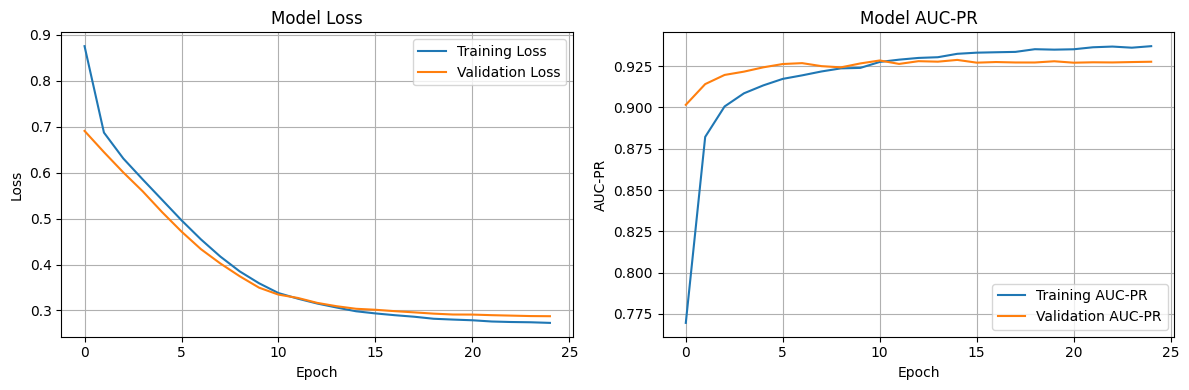

              precision    recall  f1-score   support

Negative (0)       0.94      0.97      0.95     45906
Positive (1)       0.91      0.84      0.87     18377

    accuracy                           0.93     64283
   macro avg       0.92      0.90      0.91     64283
weighted avg       0.93      0.93      0.93     64283

ROC-AUC: 0.9755  |  PR-AUC: 0.9508
{'total_params': 672257, 'latency_ms': 3.5719, 'best_val_loss': 0.2874, 'val_loss_std': 0.0045}


In [21]:
plot_training_curves(history)
metrics_ed = evaluate_classifier(model_ed, X_test, split["test_labels"])
print(get_basic_run_metrics(model_ed, history, X_val[:32]))

In [22]:
logreg_ed = train_eval_logreg(
    X_train, split["train_labels"], X_val, split["val_labels"], X_test, split["test_labels"]
)

              precision    recall  f1-score   support

         Neg       0.97      0.78      0.87     45906
         Pos       0.63      0.95      0.76     18377

    accuracy                           0.83     64283
   macro avg       0.80      0.86      0.81     64283
weighted avg       0.88      0.83      0.84     64283

ROC AUC: 0.9264  |  AUPR: 0.7852


---
## 8. Model 4: mvTCR + Peptide

Loads pre-computed mvTCR latent embeddings (generated by the mvTCR tool) and concatenates them with peptide AE embeddings.

In [ ]:
train_input_mvTCR = pd.read_csv(f"{output_dir}/merged_embeddings/mvTCR_integration_res/"
    f"10X_mvTCR_embedding_integration_latent_best_reconstruction_metric_smart_aligned_v2_train_indices_{SPLIT_TYPE}_{RUN}.csv")
val_input_mvTCR   = pd.read_csv(f"{output_dir}/merged_embeddings/mvTCR_integration_res/"
    f"10X_mvTCR_embedding_integration_latent_best_reconstruction_metric_smart_aligned_v2_val_indices_{SPLIT_TYPE}_{RUN}.csv")
test_input_mvTCR  = pd.read_csv(f"{output_dir}/merged_embeddings/mvTCR_integration_res/"
    f"10X_mvTCR_embedding_integration_latent_best_reconstruction_metric_smart_aligned_v2_test_indices_{SPLIT_TYPE}_{RUN}.csv")

X_train, X_val, X_test = assemble_features(
    (train_input_mvTCR.values, val_input_mvTCR.values, test_input_mvTCR.values),
    (emb_pep_train, emb_pep_val, emb_pep_test),
)
print(X_train.shape, X_val.shape, X_test.shape)

In [ ]:
model_mvtcr = build_residual_mlp(X_train.shape[1], name='mvtcr_pep')
history = compile_and_train(
    model_mvtcr, X_train, split["train_labels"], X_val, split["val_labels"],
    lr=1e-3, batch_size=128, epochs=60, patience=10,
)

In [ ]:
plot_training_curves(history)
metrics_mvtcr = evaluate_classifier(model_mvtcr, X_test, split["test_labels"])
print(get_basic_run_metrics(model_mvtcr, history, X_val[:32]))

In [ ]:
logreg_mvtcr = train_eval_logreg(
    X_train, split["train_labels"], X_val, split["val_labels"], X_test, split["test_labels"]
)

---
## 9. Model 5: Tessa + Peptide

Loads pre-computed Tessa TCR embeddings and concatenates them with peptide AE embeddings.

In [ ]:
train_input_Tessa = pd.read_csv(f"{output_dir}/merged_embeddings/Tessa_integration_res/"
    f"res_10X_TCR_emb_smart_aligned_v2_train_indices_{SPLIT_TYPE}_{RUN}.csv").drop(columns=["contig_id"])
val_input_Tessa   = pd.read_csv(f"{output_dir}/merged_embeddings/Tessa_integration_res/"
    f"res_10X_TCR_emb_smart_aligned_v2_val_indices_{SPLIT_TYPE}_{RUN}.csv").drop(columns=["contig_id"])
test_input_Tessa  = pd.read_csv(f"{output_dir}/merged_embeddings/Tessa_integration_res/"
    f"res_10X_TCR_emb_smart_aligned_v2_test_indices_{SPLIT_TYPE}_{RUN}.csv").drop(columns=["contig_id"])

X_train, X_val, X_test = assemble_features(
    (train_input_Tessa.values, val_input_Tessa.values, test_input_Tessa.values),
    (emb_pep_train, emb_pep_val, emb_pep_test),
)
print(X_train.shape, X_val.shape, X_test.shape)

In [ ]:
model_tessa = build_residual_mlp(X_train.shape[1], name='tessa_pep')
history = compile_and_train(
    model_tessa, X_train, split["train_labels"], X_val, split["val_labels"],
    lr=1e-3, batch_size=128, epochs=60, patience=10,
)

In [ ]:
plot_training_curves(history)
metrics_tessa = evaluate_classifier(model_tessa, X_test, split["test_labels"])
print(get_basic_run_metrics(model_tessa, history, X_val[:32]))

In [ ]:
---
## 10. Summary

vj_tag = "+VJ" if USE_VJ else ""
results = {
    "Batch GEX + Peptide":                      metrics_gex,
    "TCR Alpha+Beta + Peptide":                  metrics_tcr,
    f"ED GEX→TCR Alpha+Beta{vj_tag} + Peptide": metrics_ed,
    "mvTCR + Peptide":                           metrics_mvtcr,
    "Tessa + Peptide":                           metrics_tessa,
}

summary = pd.DataFrame(results).T
summary.columns = ["ROC-AUC", "PR-AUC"]
summary = summary.sort_values("PR-AUC", ascending=False)
print(f"Split: {SPLIT_TYPE}  Run: {RUN}  Ratio: {NEG_RATIO}  USE_VJ: {USE_VJ}\n")
print(summary.to_string(float_format="{:.4f}".format))

In [23]:
vj_tag = "+VJ" if USE_VJ else ""
results = {
    "Batch GEX + Peptide":                      metrics_gex,
    "TCR Alpha+Beta + Peptide":                  metrics_tcr,
    f"ED GEX→TCR Alpha+Beta{vj_tag} + Peptide": metrics_ed,
}

summary = pd.DataFrame(results).T
summary.columns = ["ROC-AUC", "PR-AUC"]
summary = summary.sort_values("PR-AUC", ascending=False)
print(f"Split: {SPLIT_TYPE}  Run: {RUN}  Ratio: {NEG_RATIO}  USE_VJ: {USE_VJ}\n")
print(summary.to_string(float_format="{:.4f}".format))

Split: tcr_ab_split  Run: 1  Ratio: 3_1  USE_VJ: False

                                 ROC-AUC  PR-AUC
ED GEX→TCR Alpha+Beta + Peptide   0.9755  0.9508
TCR Alpha+Beta + Peptide          0.9303  0.8159
Batch GEX + Peptide               0.9415  0.8106
